In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from tensorflow.keras import layers


img_size = 224  
batch_size = 32
patch_size = 16 

train_data = pd.read_excel('Downloads/Dataset/training/training_data.xlsx') 
val_data = pd.read_excel('Downloads/Dataset/validation/validation_data.xlsx')

train_data['image_path'] = train_data['image_path'].str.replace('\\', '/', regex=False)
val_data['image_path'] = val_data['image_path'].str.replace('\\', '/', regex=False)

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_data, 
    directory='Downloads/Dataset/',  
    x_col='image_path',
    y_col=['Angioectasia', 'Bleeding', 'Erosion', 'Erythema', 'Foreign Body', 
           'Lymphangiectasia', 'Normal', 'Polyp', 'Ulcer', 'Worms'],
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='raw'  
)

val_generator = val_datagen.flow_from_dataframe(
    val_data, 
    directory='Downloads/Dataset/', 
    x_col='image_path',
    y_col=['Angioectasia', 'Bleeding', 'Erosion', 'Erythema', 'Foreign Body', 
           'Lymphangiectasia', 'Normal', 'Polyp', 'Ulcer', 'Worms'],
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='raw'
)


Found 37607 validated image filenames.
Found 16132 validated image filenames.


In [3]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size
        self.shape_printed = False

    def call(self, images):
        if not self.shape_printed:
            tf.print("Input shape during first batch: ", tf.shape(images))
            self.shape_printed = True 
        
        batch_size = tf.shape(images)[0]  
        image_height = tf.shape(images)[1]
        image_width = tf.shape(images)[2]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patches_shape = tf.shape(patches)
        batch_size, num_patches, patch_dims = patches_shape[0], patches_shape[1] * patches_shape[2], patches_shape[3]

        patches = tf.reshape(patches, [batch_size, num_patches, patch_dims])
        return patches


In [4]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

In [5]:
def create_vit_model(input_shape=(224, 224, 3), num_classes=10, projection_dim=64, transformer_layers=8):
    inputs = layers.Input(shape=(224, 224, 3))

    patches = Patches(patch_size)(inputs)  
    num_patches = (input_shape[0] // patch_size) ** 2  

    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=projection_dim, dropout=0.1)(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        feedforward = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        feedforward = layers.Dense(projection_dim)(feedforward)
        encoded_patches = layers.Add()([feedforward, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    features = layers.Dense(128, activation=tf.nn.gelu)(representation)
    logits = layers.Dense(num_classes, activation='sigmoid')(features) 

    model = keras.Model(inputs=inputs, outputs=logits)
    return model

vit_model = create_vit_model(input_shape=(224, 224, 3), num_classes=10)

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

vit_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 patches (Patches)           (None, 196, 768)             0         ['input_1[0][0]']             
                                                                                                  
 patch_encoder (PatchEncode  (None, 196, 64)              61760     ['patches[0][0]']             
 r)                                                                                               
                                                                                                  
 layer_normalization (Layer  (None, 196, 64)              128       ['patch_encoder[0][0]']   

                                                                     'add_5[0][0]']               
                                                                                                  
 layer_normalization_7 (Lay  (None, 196, 64)              128       ['add_6[0][0]']               
 erNormalization)                                                                                 
                                                                                                  
 dense_7 (Dense)             (None, 196, 128)             8320      ['layer_normalization_7[0][0]'
                                                                    ]                             
                                                                                                  
 dense_8 (Dense)             (None, 196, 64)              8256      ['dense_7[0][0]']             
                                                                                                  
 add_7 (Ad

                                                                                                  
 multi_head_attention_7 (Mu  (None, 196, 64)              66368     ['layer_normalization_14[0][0]
 ltiHeadAttention)                                                  ',                            
                                                                     'layer_normalization_14[0][0]
                                                                    ']                            
                                                                                                  
 add_14 (Add)                (None, 196, 64)              0         ['multi_head_attention_7[0][0]
                                                                    ',                            
                                                                     'add_13[0][0]']              
                                                                                                  
 layer_nor

In [6]:
vit_model = create_vit_model(input_shape=(224, 224, 3), num_classes=10)

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

vit_model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 patches_1 (Patches)         (None, 196, 768)             0         ['input_2[0][0]']             
                                                                                                  
 patch_encoder_1 (PatchEnco  (None, 196, 64)              61760     ['patches_1[0][0]']           
 der)                                                                                             
                                                                                                  
 layer_normalization_17 (La  (None, 196, 64)              128       ['patch_encoder_1[0][0]'

 ultiHeadAttention)                                                 ',                            
                                                                     'layer_normalization_23[0][0]
                                                                    ']                            
                                                                                                  
 add_22 (Add)                (None, 196, 64)              0         ['multi_head_attention_11[0][0
                                                                    ]',                           
                                                                     'add_21[0][0]']              
                                                                                                  
 layer_normalization_24 (La  (None, 196, 64)              128       ['add_22[0][0]']              
 yerNormalization)                                                                                
          

 dense_33 (Dense)            (None, 196, 64)              8256      ['dense_32[0][0]']            
                                                                                                  
 add_29 (Add)                (None, 196, 64)              0         ['dense_33[0][0]',            
                                                                     'add_28[0][0]']              
                                                                                                  
 layer_normalization_31 (La  (None, 196, 64)              128       ['add_29[0][0]']              
 yerNormalization)                                                                                
                                                                                                  
 multi_head_attention_15 (M  (None, 196, 64)              66368     ['layer_normalization_31[0][0]
 ultiHeadAttention)                                                 ',                            
          

In [7]:
history = vit_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)


Epoch 1/10
1176/1176 [==============================] - 1800s 2s/step - loss: 0.1366 - accuracy: 0.7610 - val_loss: 0.1121 - val_accuracy: 0.7811
Epoch 2/10
1176/1176 [==============================] - 1718s 1s/step - loss: 0.1083 - accuracy: 0.7895 - val_loss: 0.0964 - val_accuracy: 0.8063
Epoch 3/10
1176/1176 [==============================] - 1762s 1s/step - loss: 0.0905 - accuracy: 0.8187 - val_loss: 0.0835 - val_accuracy: 0.8309
Epoch 4/10
1176/1176 [==============================] - 1794s 2s/step - loss: 0.0780 - accuracy: 0.8398 - val_loss: 0.0749 - val_accuracy: 0.8468
Epoch 5/10
1176/1176 [==============================] - 1772s 2s/step - loss: 0.0678 - accuracy: 0.8608 - val_loss: 0.0689 - val_accuracy: 0.8584
Epoch 6/10
1176/1176 [==============================] - 1793s 2s/step - loss: 0.0594 - accuracy: 0.8771 - val_loss: 0.0631 - val_accuracy: 0.8709
Epoch 7/10
1176/1176 [==============================] - 1878s 2s/step - loss: 0.0531 - accuracy: 0.8904 - val_loss: 0.0617 -

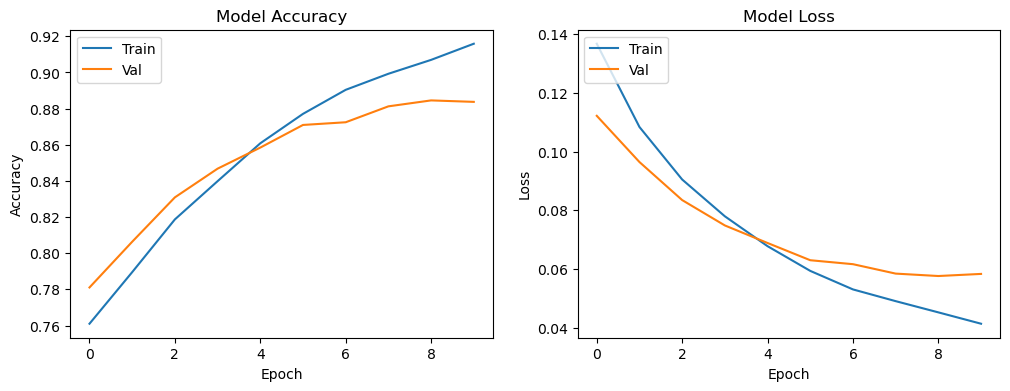

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper left')

plt.show()

In [9]:
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

val_generator.reset()
predictions = vit_model.predict(val_generator)
y_true = val_generator.labels
y_pred = np.where(predictions > 0.5, 1, 0)  # Threshold for binary classification

conf_matrix = multilabel_confusion_matrix(y_true, y_pred)
print(conf_matrix)

505/505 [==============================] - 232s 459ms/step
[[[15335   300]
  [  489     8]]

 [[15452   321]
  [  352     7]]

 [[14124   853]
  [ 1077    78]]

 [[15758    77]
  [  294     3]]

 [[15580   212]
  [  334     6]]

 [[15570   219]
  [  335     8]]

 [[  942  2903]
  [ 3105  9182]]

 [[15455   177]
  [  495     5]]

 [[15592   254]
  [  282     4]]

 [[15994    70]
  [   68     0]]]


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.03      0.02      0.02       497
           1       0.02      0.02      0.02       359
           2       0.08      0.07      0.07      1155
           3       0.04      0.01      0.02       297
           4       0.03      0.02      0.02       340
           5       0.04      0.02      0.03       343
           6       0.76      0.75      0.75     12287
           7       0.03      0.01      0.01       500
           8       0.02      0.01      0.01       286
           9       0.00      0.00      0.00        68

   micro avg       0.63      0.58      0.60     16132
   macro avg       0.10      0.09      0.10     16132
weighted avg       0.59      0.58      0.58     16132
 samples avg       0.57      0.58      0.58     16132



/Users/tanishkamisra/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [16]:
# Save the entire model
vit_model.save('vit_model_final.h5')

# Load the saved model
loaded_model = keras.models.load_model('vit_model_final.h5')

ImportError: `save_model()` using h5 format requires h5py. Could not import h5py.

In [15]:
pip install h5py


Note: you may need to restart the kernel to use updated packages.


In [ ]:
img_path = 'path_to_new_image.jpg'
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Rescale like during training

predictions = vit_model.predict(img_array)
print(predictions)